In [1]:
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
mat_file = h5py.File('C:/Users/Rounak/Desktop/OneDrive/College/Projects/DensePose Wifi/Dataset/Wi-PoseDataset/Wi-Pose/Train/walk_105-frame105.mat', 'r')


In [3]:
csi = mat_file['CSI'][:]

In [4]:
skeletonpoints = mat_file['SkeletonPoints'][:]

In [11]:
skeletonpoints.shape

(1, 54)

In [5]:
mat_file.keys()

<KeysViewHDF5 ['CSI', 'SkeletonPoints']>

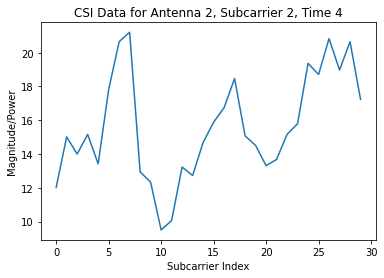

In [17]:
csi_data = mat_file['CSI']  # No need for [:] at this stage

# Visualize CSI data for the first antenna, subcarrier, and time instance
antenna_index = 2 # 0-2
subcarrier_index = 2 # 0-2
time_index = 4 # 0-4

# Get the CSI data for the specific indices
csi_slice = csi_data[antenna_index, subcarrier_index, :, time_index]

# Assuming the data is magnitude or power, you can plot it as a line plot
plt.plot(csi_slice)
plt.title(f'CSI Data for Antenna {antenna_index}, Subcarrier {subcarrier_index}, Time {time_index}')
plt.xlabel('Subcarrier Index')
plt.ylabel('Magnitude/Power')
plt.show()

In [8]:
csi_data

<HDF5 dataset "CSI": shape (3, 3, 30, 5), type "<f8">

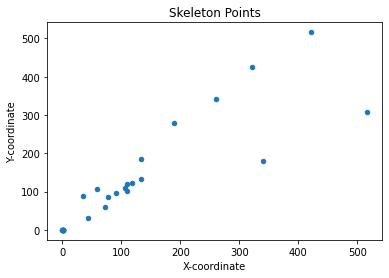

In [9]:
skeleton_points_data = skeletonpoints.reshape(-1, 2)

# Visualize SkeletonPoints data with larger points
plt.scatter(skeleton_points_data[:, 0], skeleton_points_data[:, 1], s=20)
plt.title('Skeleton Points')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

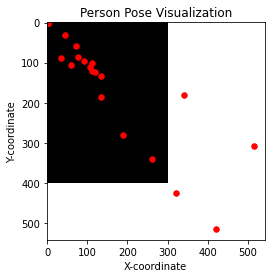

In [10]:
skeleton_points_data = mat_file['SkeletonPoints'][:]

# Reshape the data to remove the singleton dimension (from shape (1, 54) to (54,))
skeleton_points_data = skeleton_points_data.reshape(-1, 2)

# Create a blank image as a placeholder
image_size = (400, 300)  # Set the size of the blank image
image = np.ones(image_size, dtype=np.uint8) * 255  # Set all pixels to white (255)

# Visualize SkeletonPoints data on the blank image
plt.imshow(image, cmap='gray')
plt.scatter(skeleton_points_data[:, 0], skeleton_points_data[:, 1], c='r', s=30)  # Use red color for joints
plt.title('Person Pose Visualization')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

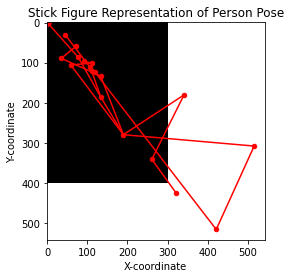

In [121]:
joint_connections = [(0, 1), (1, 2), (1, 5), (2, 3), (5, 6), (3, 4), (6, 7),
                     (1, 8), (8, 9), (9, 10), (1, 11), (11, 12), (12, 13),
                     (0, 14), (14, 15), (15, 16), (0, 17), (17, 18), (18, 19)]

# Visualize Skeleton Points as a stick figure on a blank image
plt.imshow(image, cmap='gray')

# Plot stick figure lines
for connection in joint_connections:
    plt.plot(skeleton_points_data[connection, 0], skeleton_points_data[connection, 1], 'r-')

# Plot joints as circles
plt.scatter(skeleton_points_data[:, 0], skeleton_points_data[:, 1], c='r', s=20)

plt.title('Stick Figure Representation of Person Pose')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.show()

In [136]:
mat_file.keys()

<KeysViewHDF5 ['CSI', 'SkeletonPoints']>

In [137]:
mat_file['SkeletonPoints']

<HDF5 dataset "SkeletonPoints": shape (1, 54), type "<f8">